In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

In [25]:
# Load dataset
df = pd.read_csv("secondary_data.csv", sep=';')

In [27]:
numeric_cols = ["cap-diameter", "stem-height", "stem-width"]
categorical_cols = [col for col in df.columns if col not in numeric_cols]


In [43]:
label_encoder = LabelEncoder()
df["class_encoded"] = label_encoder.fit_transform(df["class"])

In [39]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [45]:
X = df_encoded.drop(columns=["class_encoded"]) 
y = df_encoded["class_encoded"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(10)])
df_pca["class_encoded"] = y.values

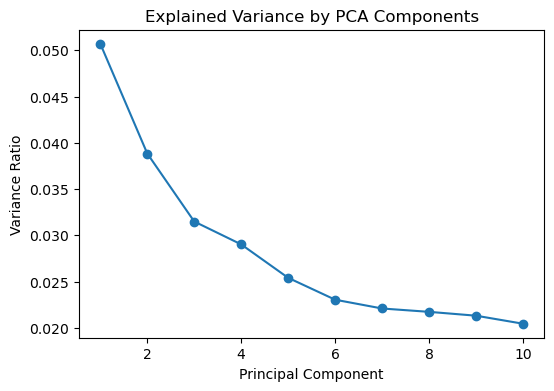

In [47]:
plt.figure(figsize=(6,4))
plt.plot(range(1, 11), pca.explained_variance_ratio_, marker="o")
plt.title("Explained Variance by PCA Components")
plt.xlabel("Principal Component")
plt.ylabel("Variance Ratio")
plt.show()

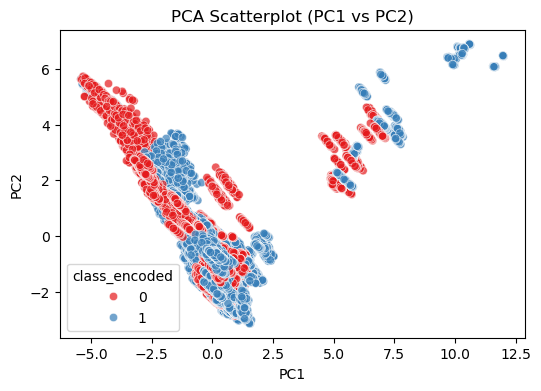

In [51]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df_pca["PC1"], y=df_pca["PC2"], hue=df_pca["class_encoded"], palette="Set1", alpha=0.7)
plt.title("PCA Scatterplot (PC1 vs PC2)")
plt.show()
